# A Simple PCA Coding Tutorial #

In this tutorial we will use the 'Iris flower species' dataset to perform dimensionality reduction from 4D to 2D subspace using PCA.

## 1. Import the dataset ##

To begin, let's first load the necessary libraries and our dataset.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

# loading the dataset
iris = load_iris()
X = iris.data
y = iris.target

print("Original features shape:", X.shape)
print("Target classes:", np.unique(y))

Original features shape: (150, 4)
Target classes: [0 1 2]


As you can see, the dataset consists of 4 features and a target variable with 3 classes for classification.

Now, let's plot the data with only the first two features for visualization.

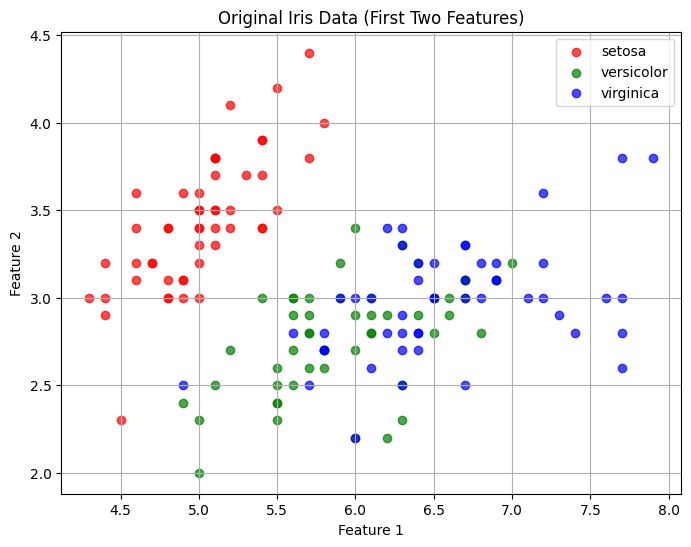

In [ ]:
plt.figure(figsize=(8, 6))
for label, color in zip(np.unique(y), ['red','green','blue']):
    plt.scatter(
        X[y==label, 0],
        X[y==label, 1],
        label=iris.target_names[label],
        alpha=0.7,
        c=color
    )
plt.title('Original Iris Data (First Two Features)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.show()

Note: As the dataset consists of 4 features, the data exists in a 4D space. It's obvious that its not only challenging to visualize the data in a 2D space but also makes it challenging for an ML algorithm to learn a decision boundary for a classificaiton task. Hence, to lower the computational load and improve prediction performance we use PCA and reduce the dimensionality of the data.

## 2. Standardize the data ##

PCA needs standardized features (zero mean, unit variance).

Therefore, we should standardize the data so that the features are comparable. We do this by subtracting the mean and dividing by the standard deviation.

In [ ]:
# Standardizing: subtract mean and divide by standard deviation

X_mean = np.mean(X, axis=0)   # mean
X_std_dev = np.std(X, axis=0) # standard deviation

X_std = (X - X_mean) / X_std_dev # standardized data

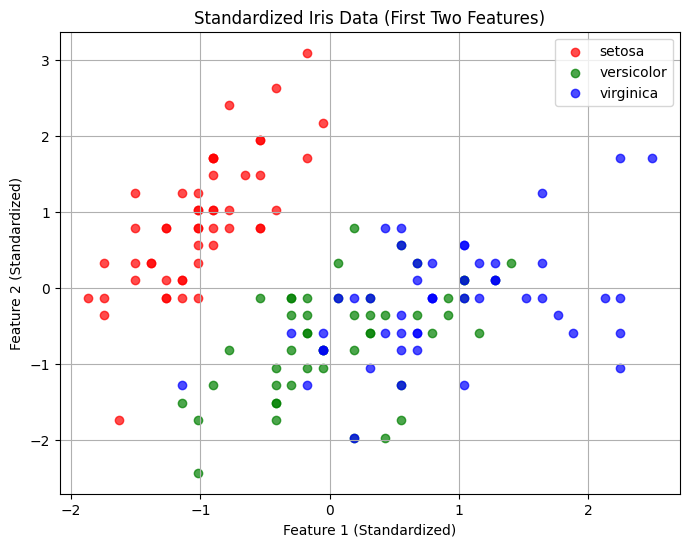

In [ ]:
# plotting
plt.figure(figsize=(8, 6))
for label, color in zip(np.unique(y), ['red','green','blue']):
    plt.scatter(
            X_std[y==label, 0],
            X_std[y==label, 1],
            label=iris.target_names[label],
            alpha=0.7,
            c=color
    )
plt.title('Standardized Iris Data (First Two Features)')
plt.xlabel('Feature 1 (Standardized)')
plt.ylabel('Feature 2 (Standardized)')
plt.legend()
plt.grid(True)
plt.show()

## 3. Compute Covariance matrix ##

The covariance matrix shows how the features vary with each other.

The covariance matrix is given by:
$$C = \frac{1}{n - 1} X^T X$$

where, X is the standardized data matrix.

In [ ]:
cov_matrix = np.cov(X_std.T)  # computing using numpy

print(cov_matrix)

[[ 1.00671141 -0.11835884  0.87760447  0.82343066]
 [-0.11835884  1.00671141 -0.43131554 -0.36858315]
 [ 0.87760447 -0.43131554  1.00671141  0.96932762]
 [ 0.82343066 -0.36858315  0.96932762  1.00671141]]


## 4. Find eigenvalues and eigenvectors ##

Eignevectors = directions (or the 'Principal components')

Eigenvalues = how much variance each component explains


In [ ]:
eig_vals, eig_vecs = np.linalg.eig(cov_matrix)

print("Eigenvalues:")
print(eig_vals)

print("\nEigenvectors:")
print(eig_vecs)

Eigenvalues:
[2.93808505 0.9201649  0.14774182 0.02085386]

Eigenvectors:
[[ 0.52106591 -0.37741762 -0.71956635  0.26128628]
 [-0.26934744 -0.92329566  0.24438178 -0.12350962]
 [ 0.5804131  -0.02449161  0.14212637 -0.80144925]
 [ 0.56485654 -0.06694199  0.63427274  0.52359713]]


## 5. Choose top 'k' components ##

Next, we will reduce the 4D data --> 2D data.

In [ ]:
k = 2 # number of principal components to keep
W = eig_vecs[:,:k] # this gives a (4, 2) projection matrix

print("Projection Matrix:\n", W)

Projection Matrix:
 [[ 0.52106591 -0.37741762]
 [-0.26934744 -0.92329566]
 [ 0.5804131  -0.02449161]
 [ 0.56485654 -0.06694199]]


## 6. Project the data ##

Transform the data into the new 2D subspace.

In [ ]:
X_pca = np.dot(X_std, W)
print("Reduced shape:", X_pca.shape)

Reduced shape: (150, 2)


In [ ]:
explained_variance_ratio = eig_vals / np.sum(eig_vals)
print("Explained variance ratio (first 2 PCs):", explained_variance_ratio[:2])

Explained variance ratio (first 2 PCs): [0.72962445 0.22850762]


As you can see, after performing PCA, the 1st component explains ~73% of the variation from the original data and the 2nd component explains ~23% of the variation.

This shows that, even after reducing the dimensionality to a 2D subspace we still capture ~96% of the variation from the original data.

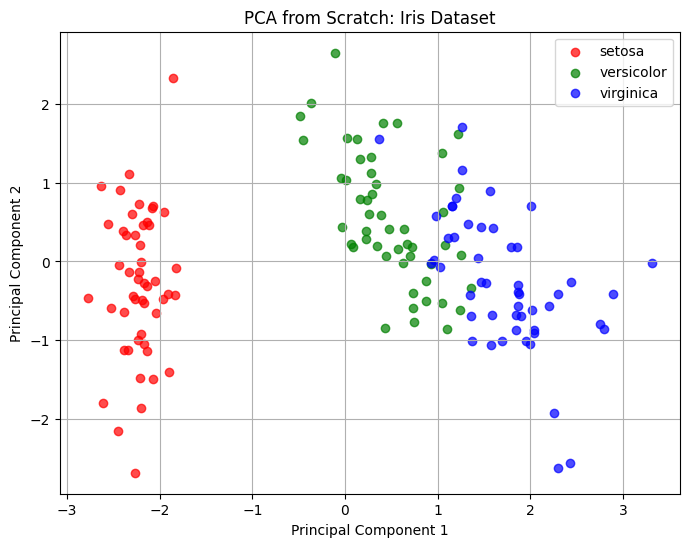

In [ ]:
plt.figure(figsize=(8,6))
for label, color in zip(np.unique(y), ['red','green','blue']):
    plt.scatter(
        X_pca[y==label, 0],
        X_pca[y==label, 1],
        label=iris.target_names[label],
        alpha=0.7,
        c=color
    )
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA from Scratch: Iris Dataset")
plt.legend()
plt.grid(True)
plt.show()


As you can observe, all of the data can now be visualized in a 2D subspace and the datapoints belonging to each class are much more seperated from eachother which helps a classificaiton algorithm learn the data in a faster and easier manner.

This demonstrates the fundamental advantage of using PCA on complicated datasets.